# Headers

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os

import pickle

import comet_ml
import json


try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG
from analysis_scripts.estimate_scripts import get_mass_distributions
from analysis_scripts.draw_scripts import total_spectrum
from analysis_scripts.draw_scripts import tssa_plot
from analysis_scripts.estimate_scripts import calculate_sb_ratio_2gauss_const
from analysis_scripts.estimate_scripts import calculate_sb_ratio_2gauss_pol2


CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


# Load Data

In [2]:
data_oc_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_1_new.csv')
data_mb_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_1_new.csv')

data_oc_df = data_oc_df.drop(['n_event'], axis=1)

mass_mask = (data_oc_df['true_decay'] == 1)
                
data_oc_df = data_oc_df[mass_mask]
data_oc_df['tag'] = 'Sig'

data_mb_df = data_mb_df.drop(['n_event'], axis=1)

data_mb_df['tag'] = 'Bg'

raw_df = pd.concat([data_oc_df, data_mb_df], axis=0).reset_index(drop=True)

raw_df['cosAngle_r_Lc_momentum_Lc_xy'] = raw_df['cosAngle_r_Lc_momentum_Lc_xy'].apply(np.cos)
raw_df['cosAngle_r_Lc_sum_momentum_xy'] = raw_df['cosAngle_r_Lc_sum_momentum_xy'].apply(np.cos)
raw_df['cosAngle_momentum_Lc_sum_momentum_xy'] = raw_df['cosAngle_momentum_Lc_sum_momentum_xy'].apply(np.cos)

In [3]:
with open("/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/preselection_mask_train_pickle.pkl", "rb") as f:
    preselection_mask = pickle.load(f)

proc_df = raw_df.query(preselection_mask).reset_index(drop=True)

proc_mass_min = proc_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].min()
proc_mass_max = proc_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].max()

In [4]:
sig_mass_distr = proc_df.loc[proc_df['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = proc_df.loc[proc_df['tag'] == 'Bg', 'mass_Lc']

# ML sel
sig_eff = 0.0538
bg_eff = 3.44e-5

total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_eff, 
    have_bg_events=CFG.have_bg_events_1 / bg_eff,
    mass_interval=(proc_mass_min, proc_mass_max),
    gev_per_bin=0.000773
)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Yield Mass Distribution'}, xlabel='Mass (GeV)', ylabel='Counts'>)

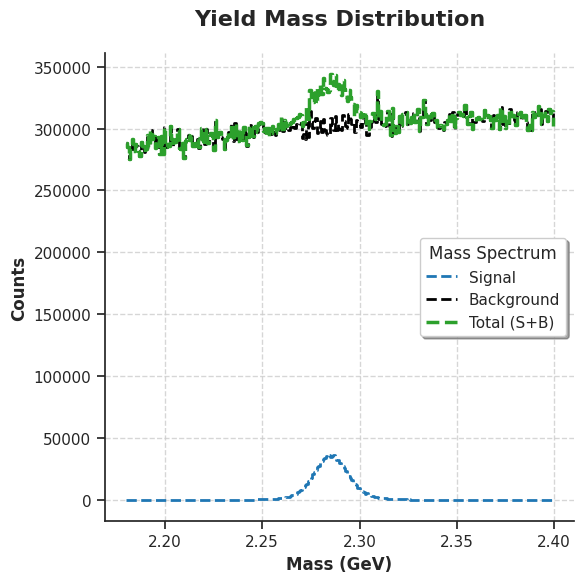

In [5]:
total_spectrum(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_eff, 
    have_bg_events=CFG.have_bg_events_1 / bg_eff,
    mass_interval=(proc_mass_min, proc_mass_max),
    gev_per_bin=0.000773,
    log_y=False,
    only_total=False,
    line_style='--'
)

# TSSA (flat bkg, presel distributions)

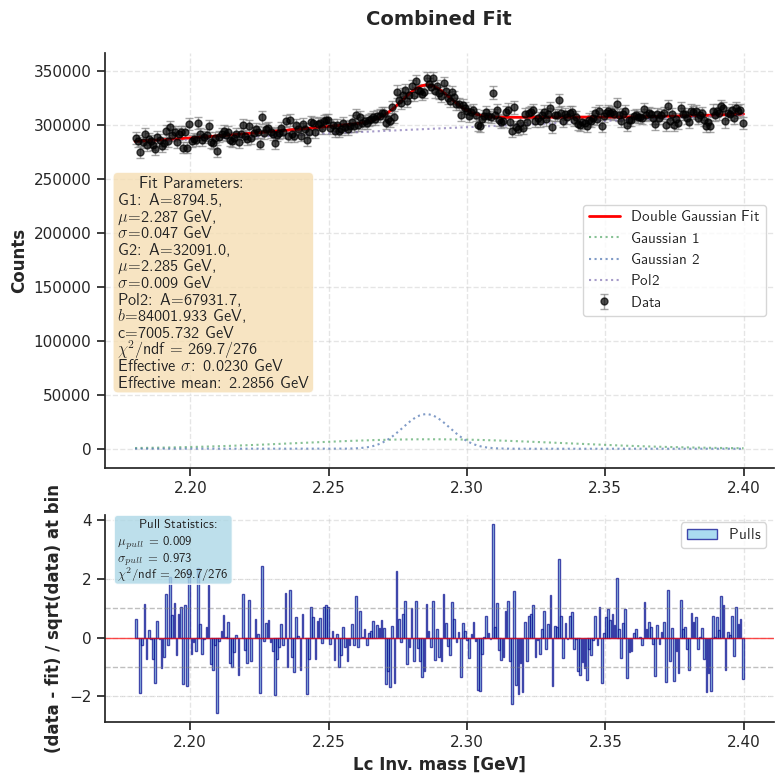

In [6]:
with open("/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/combined_fit_ML_wide_2gauss_pol2.pkl", "rb") as f:
    fit_result = pickle.load(f)

In [7]:
stat_data = calculate_sb_ratio_2gauss_pol2(
    fit_result[0]['params'],
    bin_edges,
    cov_matrix=fit_result[0]['cov_matrix'],
    mass_interval=CFG.mass_interval
)

stat_data

{'signal': np.float64(1294.7204444282436),
 'background': np.float64(22939.738995322143),
 'S_B_ratio': np.float64(0.056440068681350826),
 'integration_range': (2.24763, 2.32497),
 'S_B_uncertainty': np.float64(0.0018998480615516281)}

In [ ]:
# mean = 2.2856

# min_raw = 2.18 (mean - 11.55 small sigma) (mean - 4.50 small sigma)
# max_raw = 2.4 (mean + 12.36 small sigma) (mean + 4.82 big sigma)

# sigma MC = 0.0092 (mass_interval(2.24763, 2.32497) = +-4.2 sigma)
# sigma CF = 0.023 (mass_interval(2.24763, 2.32497) = +-1.6 sigma)



# right peak = 2.3001 (+-1.5 sigma small)
# left peak = 2.2725 

# right left bg = 2.3139 (3 sigma small)
# right right bg = 2.3231 (4 sigma small)

# left right bg = 2.2587 (3 sigma small)
# left left bg = 2.2495 (4 sigma small)



# right peak = 2.3217 (+-1.5 sigma big)
# left peak = 2.2509

# right left bg = 2.3571 (3 sigma big)
# right right bg = 2.3807 (4 sigma big) or max

# left right bg = 2.2155 (3 sigma big)
# left left bg = 2.1919 (4 sigma big) or min

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Yield Mass Distribution'}, xlabel='Mass (GeV)', ylabel='Counts'>)

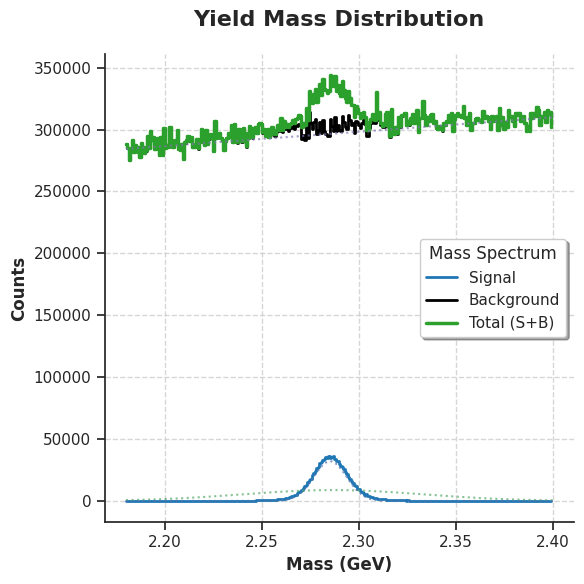

In [ ]:
[left_left_bg, left_right_bg, left_sif, right_sig, right_left_bg, right_right_bg]

tssa_plot(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1,
    have_bg_events=CFG.have_bg_events_1,
    fit_params=fit_result[0]['params'],
    sig_eff=sig_eff,
    bg_eff=bg_eff,
    mass_interval=(proc_mass_min, proc_mass_max),
    gev_per_bin=0.000773,  # (2.32497 - 2.24763) / 100
    log_y=False,
    total=True,
    only_total=False,
    line_style='-'
)